In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
complaints = pd.read_csv("complaints.csv")
drivers = pd.read_csv("drivers.csv")
vehicles = pd.read_csv("vehicles.csv")
hubs = pd.read_csv("hubs.csv")

In [3]:
print(orders.head())
print(deliveries.head())

  order_id customer_id service_type     order_created_at  \
0   O00001       C0292    Passenger  2024-08-20 14:43:00   
1   O00002       C0459    Passenger  2024-05-14 22:16:00   
2   O00003       C0161    Passenger  2025-09-02 14:37:00   
3   O00004       C0520       Parcel  2025-01-11 17:15:00   
4   O00005       C0558       Retail  2025-02-17 19:32:00   

   promised_window_hours pickup_zone dropoff_zone priority_level  order_value  \
0                      6     Airport        South         Medium       126.65   
1                     24       North      AIRPORT            Low       109.30   
2                      4        West      AIRPORT           High        33.50   
3                      2   RiverSide        North         Medium        10.04   
4                     12   Riverside        SOUTH            Low       125.58   

  booking_channel  special_handling_flag  
0             App                      0  
1             App                      0  
2           Phone      

In [4]:
print("Orders missing values:")
print(orders.isnull().sum())

print("\nDeliveries missing values:")
print(deliveries.isnull().sum())

print("\nComplaints missing values:")
print(complaints.isnull().sum())

Orders missing values:
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

Deliveries missing values:
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64

Complaints missing values:
complaint_id            0
customer_id             0
order_id                0
complaint_type          0
channel        

In [5]:
merged = deliveries.merge(orders, on="order_id", how="left")
merged = merged.merge(hubs, on="hub_id", how="left")

print(merged.head())
print(merged.shape)

  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  ...  pickup_zone  dropoff_zone  \
0                            1  ...      Central       CENTRAL   
1       

In [6]:
merged["failure_flag"] = merged["delivery_status"].apply(
    lambda x: 1 if x in ["Late", "Failed"] else 0
)

print(merged[["delivery_status", "failure_flag"]].head(10))

  delivery_status  failure_flag
0          Failed             1
1          OnTime             0
2          OnTime             0
3         Delayed             0
4          OnTime             0
5         Delayed             0
6         Delayed             0
7          OnTime             0
8          OnTime             0
9          Failed             1


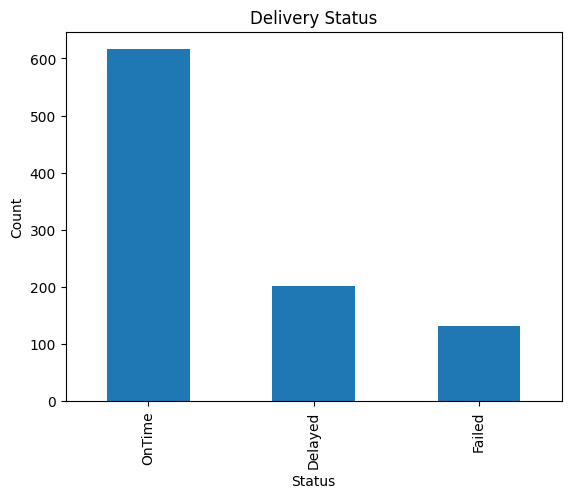

In [7]:
merged["delivery_status"].value_counts().plot(kind="bar")

plt.title("Delivery Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

In [8]:
json_data = merged.head(50).to_json(
    orient="records",
    indent=4
)

with open("northstar.json", "w") as f:
    f.write(json_data)

print("northstar.json file created successfully")

northstar.json file created successfully
